Initation files

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
%matplotlib inline

In [27]:
df = pd.read_csv('6210545459-hw#2_data.csv')
df.head()

,Date,Medication Revenue,Lab Cost,Consultation Revenue,Doctor Type,Financial Class,Patient Type,Entry Time,Post-Consultation Time,Completion Time,Patient ID
0,11/4/2019,"$1,183.22",$10.00,$20.17,ANCHOR,HMO,OUTPATIENT,8:35:45,9:17:54,9:29:46,C10001
1,11/6/2019 0:00,$738.48,$-,$15.00,ANCHOR,INSURANCE,OUTPATIENT,19:19:16,21:02:36,21:24:07,C10002
2,11/2/2019,$660.00,$-,$21.17,ANCHOR,HMO,OUTPATIENT,10:46:52,11:56:25,12:06:28,C10003
3,11/6/2019,$600.00,$-,$-,ANCHOR,MEDICARE,OUTPATIENT,9:38:34,10:55:50,10:58:02,C10004
4,11/1/2019,$591.60,$-,$12.00,ANCHOR,INSURANCE,OUTPATIENT,11:16:21,12:06:49,12:06:54,C10005


In [28]:
null_percent = df.isnull().sum()/len(df)*100
null_percent

Date                      0.0
 Medication Revenue       0.0
  Lab Cost                0.0
 Consultation Revenue     0.0
Doctor Type               0.0
Financial Class           0.0
Patient Type              0.0
Entry Time                0.0
Post-Consultation Time    0.0
Completion Time           0.0
Patient ID                0.0
dtype: float64

In [29]:
# Entry to post consult interval
df['Post-Consultation Time'] = pd.to_datetime(df['Post-Consultation Time'])
df['Entry Time'] = pd.to_datetime(df['Entry Time'])
df['Entry to consult'] = df['Post-Consultation Time'] - df['Entry Time']


# Post consult to complete interval
df['Post-Consultation Time'] = pd.to_datetime(df['Post-Consultation Time'])
df['Completion Time'] = pd.to_datetime(df['Completion Time'])
df['Post consult to Complete'] = df['Completion Time'] - df['Post-Consultation Time']

# All process time
df['All process time'] = df['Entry to consult'] + df['Post consult to Complete']

In [30]:
df

,Date,Medication Revenue,Lab Cost,Consultation Revenue,Doctor Type,Financial Class,Patient Type,Entry Time,Post-Consultation Time,Completion Time,Patient ID,Entry to consult,Post consult to Complete,All process time
0,11/4/2019,"$1,183.22",$10.00,$20.17,ANCHOR,HMO,OUTPATIENT,2024-01-27 08:35:45,2024-01-27 09:17:54,2024-01-27 09:29:46,C10001,0 days 00:42:09,0 days 00:11:52,0 days 00:54:01
1,11/6/2019 0:00,$738.48,$-,$15.00,ANCHOR,INSURANCE,OUTPATIENT,2024-01-27 19:19:16,2024-01-27 21:02:36,2024-01-27 21:24:07,C10002,0 days 01:43:20,0 days 00:21:31,0 days 02:04:51
2,11/2/2019,$660.00,$-,$21.17,ANCHOR,HMO,OUTPATIENT,2024-01-27 10:46:52,2024-01-27 11:56:25,2024-01-27 12:06:28,C10003,0 days 01:09:33,0 days 00:10:03,0 days 01:19:36
3,11/6/2019,$600.00,$-,$-,ANCHOR,MEDICARE,OUTPATIENT,2024-01-27 09:38:34,2024-01-27 10:55:50,2024-01-27 10:58:02,C10004,0 days 01:17:16,0 days 00:02:12,0 days 01:19:28
4,11/1/2019,$591.60,$-,$12.00,ANCHOR,INSURANCE,OUTPATIENT,2024-01-27 11:16:21,2024-01-27 12:06:49,2024-01-27 12:06:54,C10005,0 days 00:50:28,0 days 00:00:05,0 days 00:50:33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29993,11/13/2019,$-,$-,$-,ANCHOR,PRIVATE,OUTPATIENT,2024-01-27 14:01:24,2024-01-27 14:08:56,2024-01-27 14:15:42,C39995,0 days 00:07:32,0 days 00:06:46,0 days 00:14:18
29994,11/13/2019,$-,$-,$-,ANCHOR,PRIVATE,OUTPATIENT,2024-01-27 14:01:33,2024-01-27 14:21:17,2024-01-27 14:21:53,C39996,0 days 00:19:44,0 days 00:00:36,0 days 00:20:20
29995,11/13/2019,$-,$-,$-,ANCHOR,PRIVATE,OUTPATIENT,2024-01-27 14:01:41,2024-01-27 14:13:57,2024-01-27 14:16:29,C39997,0 days 00:12:16,0 days 00:02:32,0 days 00:14:48
29996,11/13/2019,$-,$-,$-,LOCUM,CORPORATE,OUTPATIENT,2024-01-27 14:01:42,2024-01-27 14:13:21,2024-01-27 14:13:22,C39998,0 days 00:11:39,0 days 00:00:01,0 days 00:11:40


1. Does the financial type affect the waiting time? Explain with appropriate
chart

In [31]:
distinct_financial_class = df['Financial Class'].unique()
distinct_financial_class

array(['HMO', 'INSURANCE', 'MEDICARE', 'CORPORATE', 'PRIVATE'],
      dtype=object)

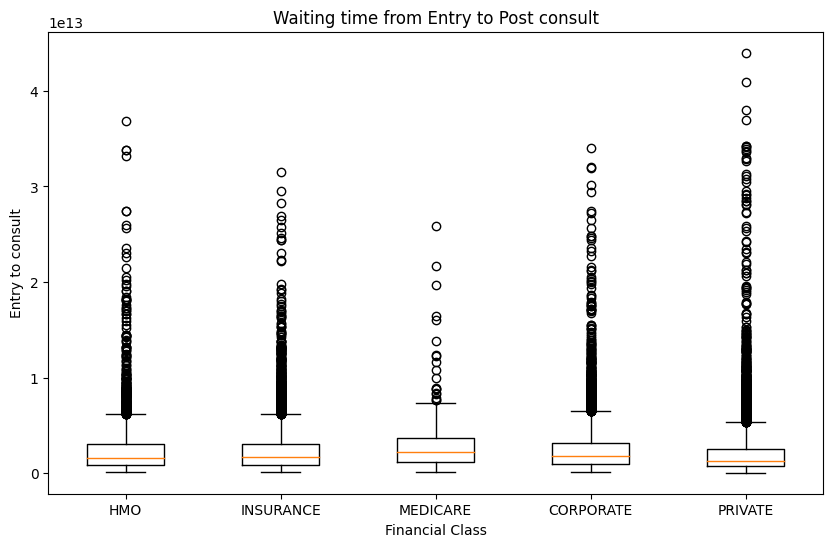

In [56]:
# Create a box plot
plt.figure(figsize=(10, 6))
plt.title('Waiting time from Entry to Post consult')
plt.xlabel('Financial Class')
plt.ylabel('Entry to consult')

# Use boxplot to visualize the distribution
plt.boxplot([df['Entry to consult'][df['Financial Class'] == 'HMO'],
             df['Entry to consult'][df['Financial Class'] == 'INSURANCE'],
             df['Entry to consult'][df['Financial Class'] == 'MEDICARE'],
             df['Entry to consult'][df['Financial Class'] == 'CORPORATE'],
             df['Entry to consult'][df['Financial Class'] == 'PRIVATE']],
            labels=['HMO', 'INSURANCE', 'MEDICARE', 'CORPORATE', 'PRIVATE'])

plt.show()

In [49]:
average_waiting = df.groupby('Financial Class')['Entry to consult'].mean().reset_index()
average_waiting

,Financial Class,Entry to consult
0,CORPORATE,0 days 00:42:23.572668112
1,HMO,0 days 00:41:02.384430176
2,INSURANCE,0 days 00:38:35.561272782
3,MEDICARE,0 days 00:50:18.853242320
4,PRIVATE,0 days 00:35:23.410371669


2. What days of week are affected ? Explain with appropriate chart

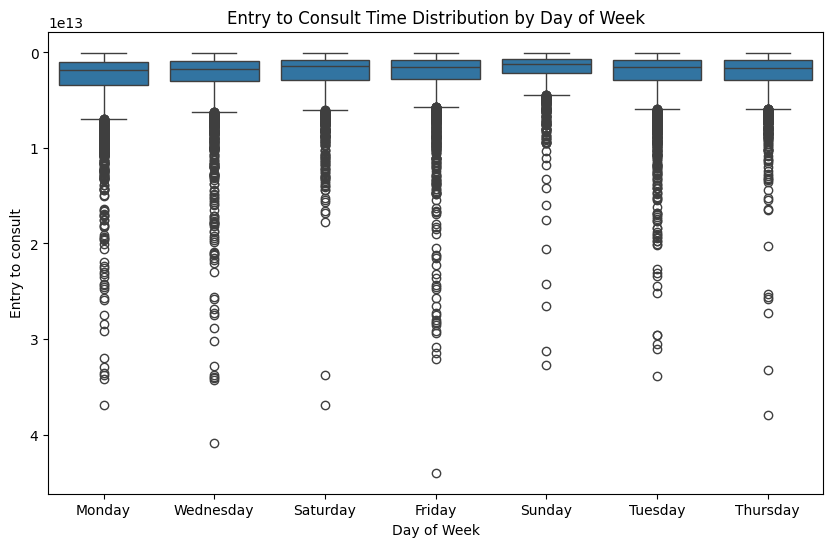

In [53]:
df['Date'] = pd.to_datetime(df['Date'])
df['Day of Week'] = df['Date'].dt.day_name()

plt.figure(figsize=(10, 6))
plt.title('Entry to Consult Time Distribution by Day of Week')
sns.boxplot(x='Day of Week', y='Entry to consult', data=df)
plt.show()

In [54]:
average_waiting_by_day_of_week = df.groupby('Day of Week')['Entry to consult'].mean().reset_index()
average_waiting_by_day_of_week

,Day of Week,Entry to consult
0,Friday,0 days 00:37:48.337395896
1,Monday,0 days 00:43:44.093812661
2,Saturday,0 days 00:37:08.025913621
3,Sunday,0 days 00:29:05.684189878
4,Thursday,0 days 00:37:44.330714552
5,Tuesday,0 days 00:37:40.263444639
6,Wednesday,0 days 00:41:53.348597458


3. Are waiting times associated with the busy periods (morning hours)?
Explain with appropriate chart

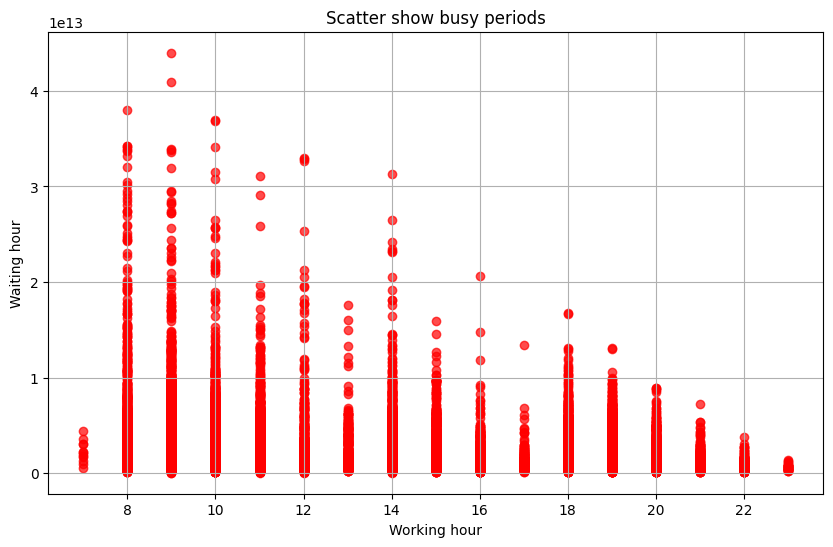

In [61]:
df['Hour'] = df['Entry Time'].dt.hour

plt.figure(figsize=(10, 6))
plt.scatter(df['Hour'], df['Entry to consult'], color='red', alpha=0.7)
plt.xlabel('Working hour')
plt.ylabel('Waiting hour')
plt.title('Scatter show busy periods')

plt.grid(True)
plt.show()